In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
plt.style.use('seaborn-v0_8')

# main dataset — for all EDA plots
df = pd.read_csv(r'C:\Users\prith\Downloads\airbnb-data-pipeline\airbnb-data-pipeline\data\processed\featured_engineered_data.csv')

# test splits — for actual vs predicted plot
X_test = pd.read_csv(r'C:\Users\prith\Downloads\airbnb-data-pipeline\airbnb-data-pipeline\data\output\X_test.csv')
y_test = pd.read_csv(r'C:\Users\prith\Downloads\airbnb-data-pipeline\airbnb-data-pipeline\data\output\y_test.csv').squeeze()

# load model for predictions
import joblib
model = joblib.load(r'C:\Users\prith\Downloads\airbnb-data-pipeline\airbnb-data-pipeline\models\xgboost_airbnb_model.pkl')

print(df.shape)
print(df.columns.tolist())

(20521, 43)
['hosts_time_as_host_years', 'host_is_superhost', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'maximum_nights', 'maximum_nights_avg_ntm', 'has_availability', 'number_of_reviews', 'estimated_occupancy_l365d', 'days_since_first_review', 'days_since_last_review', 'has_reviews', 'review_scores_cleanliness', 'review_scores_location', 'calculated_host_listings_count', 'amenity_count', 'has_wifi', 'has_kitchen', 'has_air_conditioning', 'has_dedicated_workspace', 'has_tv', 'has_heating', 'has_refrigerator', 'has_microwave', 'has_washer', 'has_dishwasher', 'has_elevator', 'has_gym', 'availability_rate', 'price_per_person', 'price_per_bedroom', 'log_price', 'host_experience_level', 'total_availability_score', 'review_score_avg']


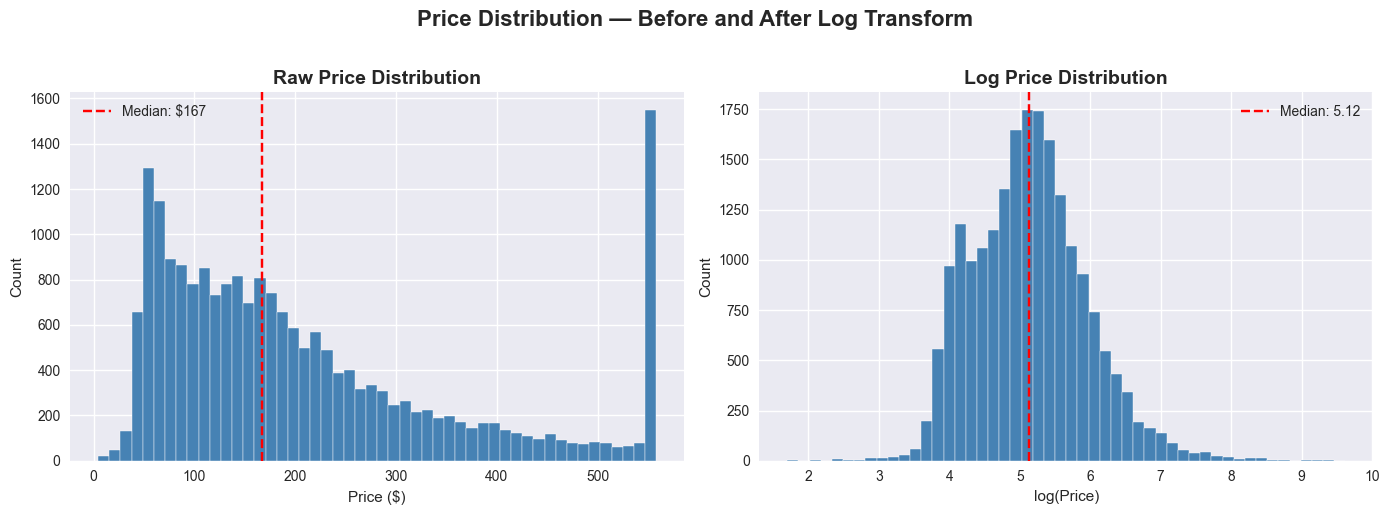

Plot 1 saved


C:\Users\prith\AppData\Local\Temp\ipykernel_14420\628546580.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_borough, labels=boroughs, patch_artist=True, notch=False)


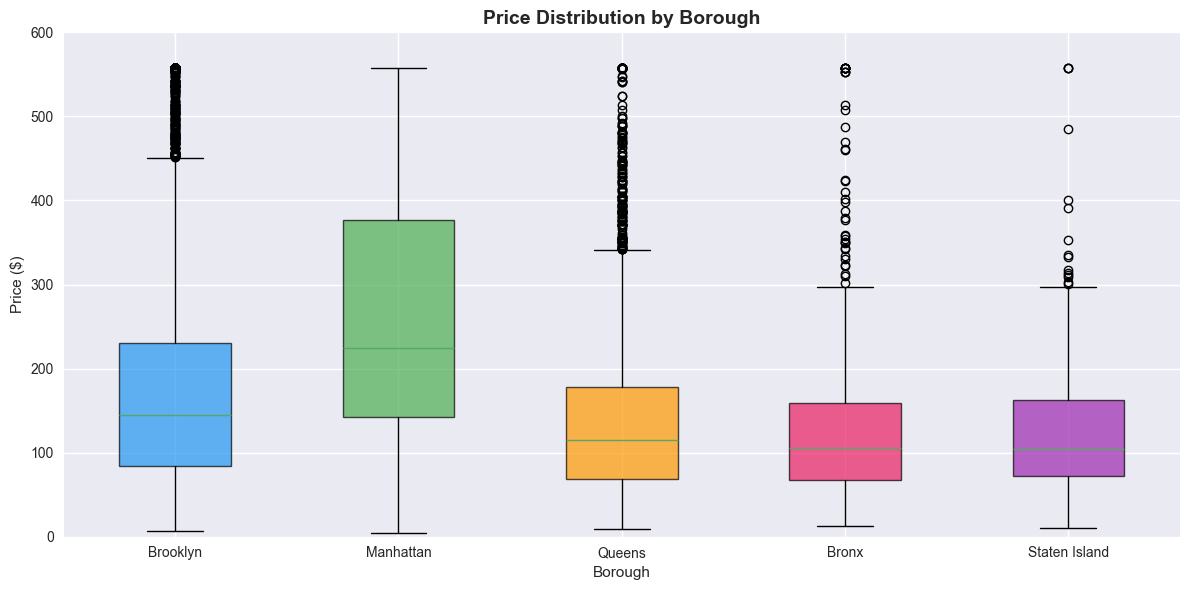

Plot 2 saved


C:\Users\prith\AppData\Local\Temp\ipykernel_14420\628546580.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(data_by_room, labels=room_types, patch_artist=True)


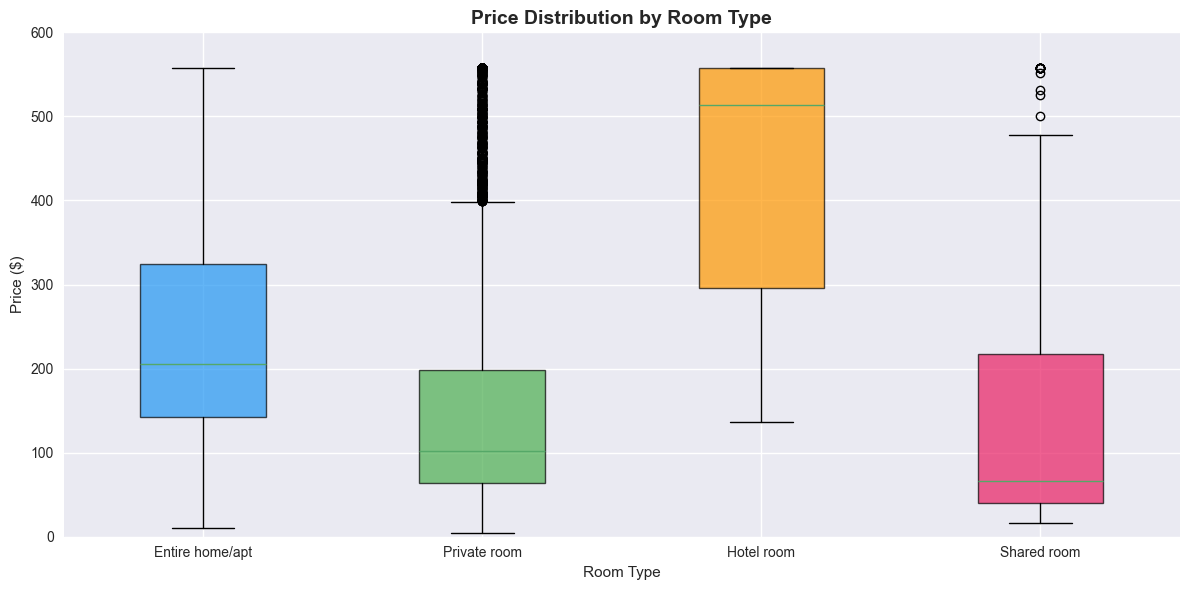

Plot 3 saved


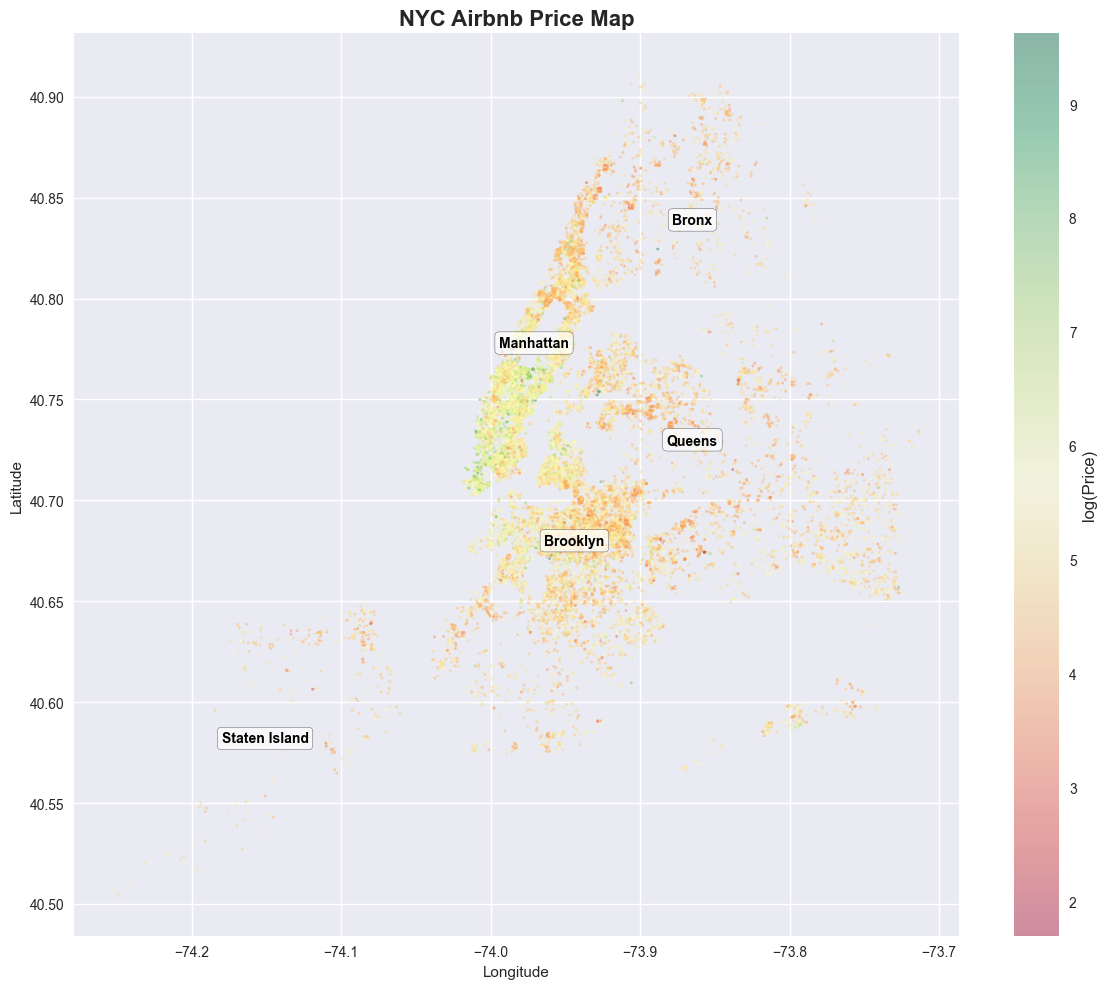

Plot 4 saved


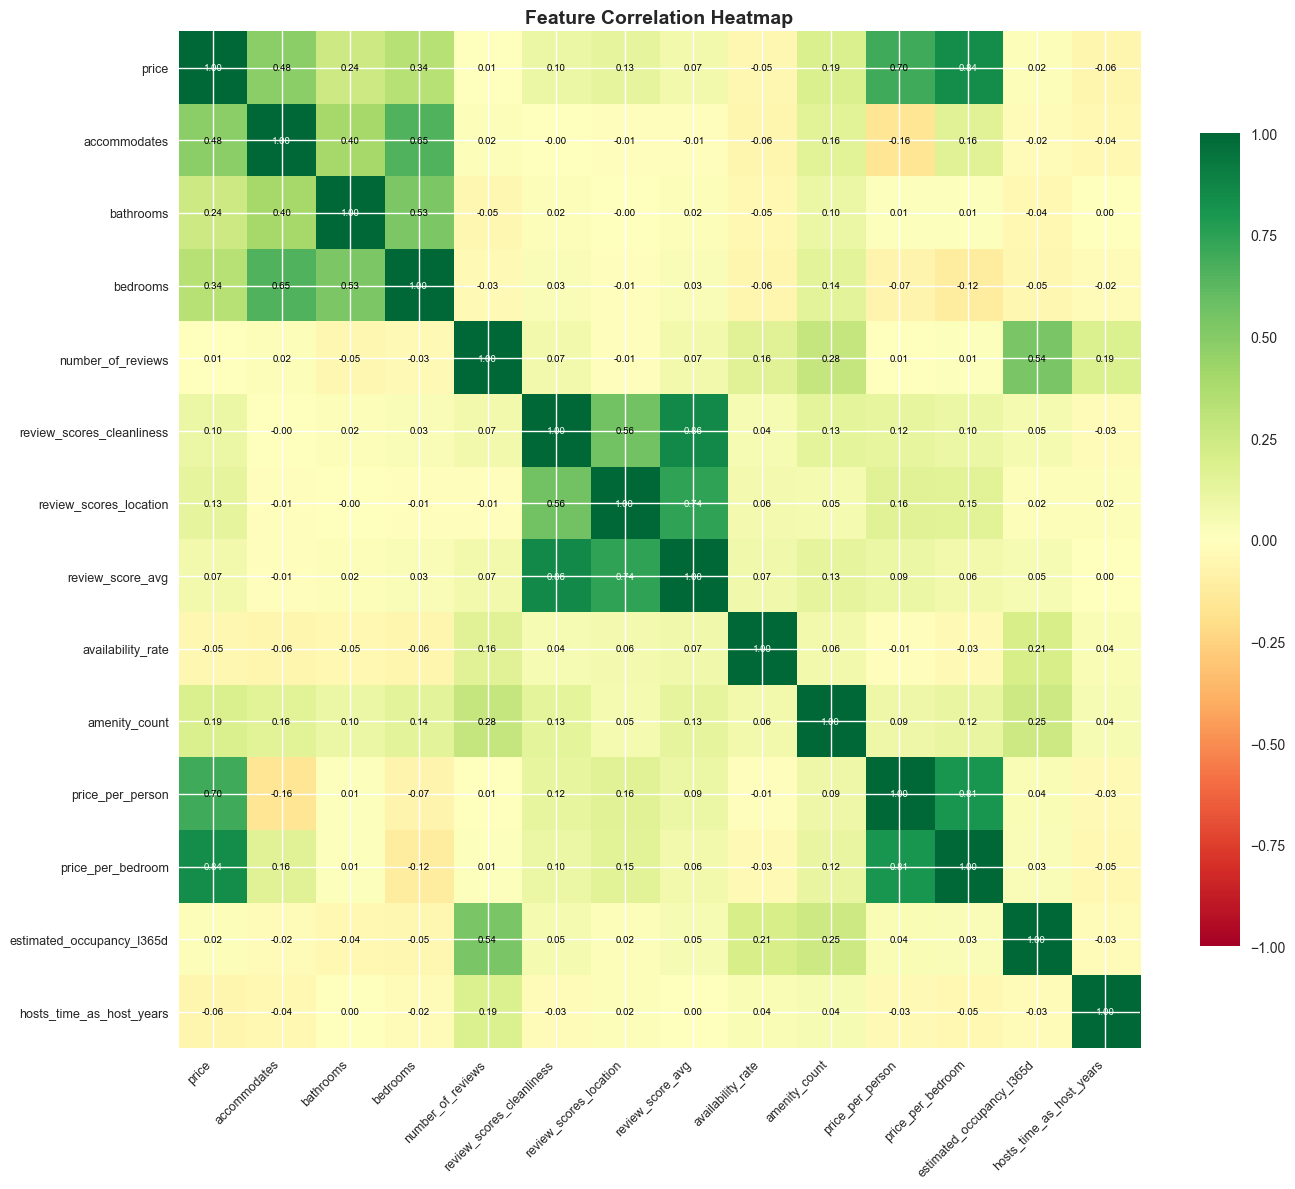

Plot 5 saved


In [ ]:
# ── PLOT 1: Price Distribution Before and After Log Transform ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df['price'], bins=50, color='steelblue', edgecolor='white')
ax1.set_title('Raw Price Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Price ($)')
ax1.set_ylabel('Count')
ax1.axvline(df['price'].median(), color='red', linestyle='--', label=f"Median: ${df['price'].median():.0f}")
ax1.legend()

ax2.hist(df['log_price'], bins=50, color='steelblue', edgecolor='white')
ax2.set_title('Log Price Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('log(Price)')
ax2.set_ylabel('Count')
ax2.axvline(df['log_price'].median(), color='red', linestyle='--', label=f"Median: {df['log_price'].median():.2f}")
ax2.legend()

plt.suptitle('Price Distribution — Before and After Log Transform', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved")

# ── PLOT 2: Price by Borough ──
fig, ax = plt.subplots(figsize=(12, 6))

boroughs = df['neighbourhood_group_cleansed'].unique()
data_by_borough = [df[df['neighbourhood_group_cleansed'] == b]['price'].values for b in boroughs]

bp = ax.boxplot(data_by_borough, labels=boroughs, patch_artist=True, notch=False)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Price Distribution by Borough', fontsize=14, fontweight='bold')
ax.set_xlabel('Borough')
ax.set_ylabel('Price ($)')
ax.set_ylim(0, 600)
plt.tight_layout()
plt.savefig('../plots/02_price_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved")

# ── PLOT 3: Price by Room Type ──
fig, ax = plt.subplots(figsize=(12, 6))

room_types = df['room_type'].unique()
data_by_room = [df[df['room_type'] == r]['price'].values for r in room_types]

bp2 = ax.boxplot(data_by_room, labels=room_types, patch_artist=True)
colors2 = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for patch, color in zip(bp2['boxes'], colors2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Price Distribution by Room Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Room Type')
ax.set_ylabel('Price ($)')
ax.set_ylim(0, 600)
plt.tight_layout()
plt.savefig('../plots/03_price_by_room_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved")

# ── PLOT 4: Geographic Price Map ──
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    df['longitude'],
    df['latitude'],
    c=df['log_price'],
    cmap='RdYlGn',
    alpha=0.4,
    s=3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('log(Price)', fontsize=12)

# add borough labels manually
borough_centers = {
    'Manhattan':   (-73.971, 40.776),
    'Brooklyn':    (-73.944, 40.678),
    'Queens':      (-73.865, 40.728),
    'Bronx':       (-73.865, 40.837),
    'Staten Island': (-74.151, 40.580)
}
for borough, (lon, lat) in borough_centers.items():
    ax.annotate(borough, (lon, lat), fontsize=10, fontweight='bold',
                color='black', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_title('NYC Airbnb Price Map', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('../plots/04_price_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved")

# ── PLOT 5: Correlation Heatmap ──
numeric_cols = [
    'price', 'accommodates', 'bathrooms', 'bedrooms',
    'number_of_reviews', 'review_scores_cleanliness',
    'review_scores_location', 'review_score_avg',
    'availability_rate', 'amenity_count',
    'price_per_person', 'price_per_bedroom',
    'estimated_occupancy_l365d', 'hosts_time_as_host_years'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)

# annotate cells with correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(val) < 0.7 else 'white')

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved")

# i used gemini here to help me plot the graphs.